Assignment for day 1
1. Install miniconda if required (https://docs.conda.io/en/latest/miniconda.html)
2. Install conda environment by running: conda env create -f environment.yml
3. Verify environment is activated and run this notebook
* either in the IDE
* or by running a jupyter server on localhost: jupyter notebook --ip=0.0.0.0

In [1]:
# imports
import pandas as pd
import yfinance as yf
import plotly.express as px

In [2]:
# parameters
TICKERS = ["AAPL", "NVDA", "MSFT"]
START_DATE = "2025-01-01"
END_DATE = "2026-03-16"

In [3]:
# download OHLCV data for tickers
print(f"Downloading data for: {', '.join(TICKERS)}")
prices = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
# auto_adjust: adjust prices for price actions. Recommended for clean prices.

prices.head()

/opt/miniconda3/envs/algotrading/lib/python3.11/site-packages/yfinance/scrapers/history.py:172: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  3 of 3 completed

3 Failed downloads:
['AAPL', 'NVDA', 'MSFT']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Empty DataFrame
Columns: [(Adj Close, AAPL), (Adj Close, MSFT), (Adj Close, NVDA), (Close, AAPL), (Close, MSFT), (Close, NVDA), (High, AAPL), (High, MSFT), (High, NVDA), (Low, AAPL), (Low, MSFT), (Low, NVDA), (Open, AAPL), (Open, MSFT), (Open, NVDA), (Volume, AAPL), (Volume, MSFT), (Volume, NVDA)]
Index: []

In [4]:
# extract close prices
close = prices["Adj Close"]
close.columns.name = None  # remove the "Price" multi-index
close.head()


,AAPL,MSFT,NVDA
Date,,,


In [5]:
# fallback to cached prices if yfinance fails
if close.empty:
    cached_all = []
    print("Failed to download data from yfinance. Trying cached prices...")
    for ticker in TICKERS:
        try:
            cached_prices = pd.read_csv(f"../../market_data/daily/{ticker}.csv")
            close_ticker = cached_prices[["Date", "Close"]].set_index("Date")
            close_ticker.index = pd.to_datetime(close_ticker.index)
            close_ticker.columns = [ticker]
            cached_all.append(close_ticker)
        except FileNotFoundError:
            continue
close = pd.concat(cached_all, axis=1)    # default is axis=0
close = close.sort_index(ascending=True)    # pct_change requires sorted index
close = close.drop_duplicates()

close.head()

Failed to download data from yfinance. Trying cached prices...


,AAPL,NVDA,MSFT
Date,,,
2025-01-02,242.525177,138.264679,414.568604
2025-01-03,242.037827,144.422684,419.292938
2025-01-06,243.668900,149.381042,423.749786
2025-01-07,240.894073,140.094086,418.322266
2025-01-08,241.381409,140.064117,420.491241


In [6]:
# run quick statistics
close.describe().round(2)

,AAPL,NVDA,MSFT
count,297.00,297.00,297.00
mean,236.51,158.89,456.56
std,27.12,29.72,49.93
min,171.67,94.29,351.87
25%,211.69,133.53,408.27
50%,236.25,173.69,471.04
75%,260.81,183.20,502.90
max,285.92,207.02,539.83


<Axes: xlabel='Date'>

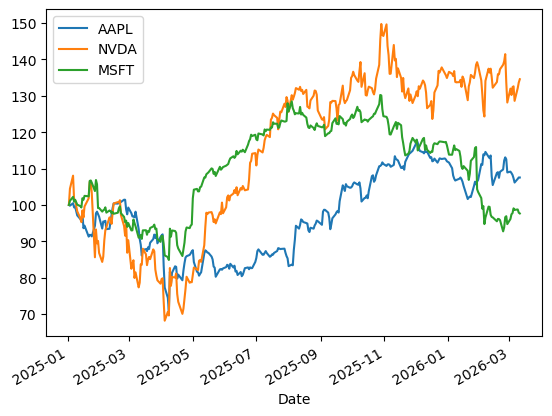

In [7]:
# normalize to 100 at start
df_normalized = (close / close.iloc[0]) * 100

# plot normalized close prices
df_normalized.plot()


In [8]:
# plot normalized close prices with plotly
fig = px.line(df_normalized, y=df_normalized.columns, title="Normalized Close Prices", template="plotly_dark")
# rename legend to: Ticker
fig.update_layout(legend_title_text="Ticker")
# remove xaxis title
fig.update_layout(xaxis_title=None)
# remove yaxis title
fig.update_layout(yaxis_title="Price Index")
# set size
fig.update_layout(width=900, height=600)
fig.show()